### MCMC

In [ ]:
### M-H采样
import random
from scipy.stats import norm
import matplotlib.pyplot as plt

def smooth_dist(theta):
    y = norm.pdf(theta, loc=3, scale=2)
    return y

def MH_sample(T, sigma):
    pi = [0 for i in range(T)]
    t = 0
    while t < T-1:
        t = t + 1
        pi_star = norm.rvs(loc=pi[t-1], scale=sigma, size=1, random_state=None)  
        alpha = min(1, (smooth_dist(pi_star[0]) / smooth_dist(pi[t-1])))   
        u = random.uniform(0, 1)
        if u < alpha:
            pi[t] = pi_star[0]
        else:
            pi[t] = pi[t-1]
    return pi
    
pi = MH_sample(10000, 1)

plt.scatter(pi, norm.pdf(pi, loc=3, scale=2), label='Target Distribution')
plt.hist(pi, 100, density=True, facecolor='red', alpha=0.6, label='Samples Distribution')
plt.legend()
plt.show();

In [ ]:
### Gibbs采样
import math
import numpy as np
from scipy.stats import multivariate_normal

target_distribution = multivariate_normal(mean=[5,-1], cov=[[1,0.5],[0.5,2]])

def p_yx(x, mu1, mu2, sigma1, sigma2, rho):
    cond_mean = mu2 + rho * sigma2 / sigma1 * (x - mu1)
    cond_std = math.sqrt(1 - rho ** 2) * sigma2
    return np.random.normal(cond_mean, cond_std)

def p_xy(y, mu1, mu2, sigma1, sigma2, rho):
    cond_mean = mu1 + rho * sigma1 / sigma2 * (y - mu2)
    cond_std = math.sqrt(1 - rho ** 2) * sigma1
    return np.random.normal(cond_mean, cond_std)

def Gibbs_sample(N, K):
    x_res, y_res, z_res = [], [], []
    x, y = 0, 0  # 初始状态
    for i in range(N):
        for j in range(K):
            x = p_xy(y, 5, -1, 1, 2, 0.5)  # 给定 y 采样 x
            y = p_yx(x, 5, -1, 1, 2, 0.5)  # 给定 x 采样 y
            z = target_distribution.pdf([x, y])
            x_res.append(x)
            y_res.append(y)
            z_res.append(z)
    return x_res, y_res, z_res

x_res, y_res, z_res = Gibbs_sample(10000, 50)

num_bins = 50
plt.hist(x_res, num_bins, density=True, facecolor='red', alpha=0.5, label='x')
plt.hist(y_res, num_bins, density=True, facecolor='dodgerblue', alpha=0.5, label='y')
plt.title('Sampling histogram of x and y')
plt.legend()
plt.show();

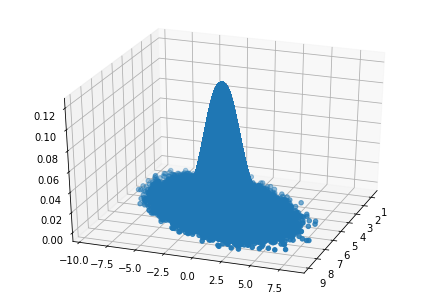

In [4]:
# 绘制抽样样本的二维正态分布
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig, rect=[0, 0, 1, 1], elev=30, azim=20)
ax.scatter(x_res, y_res, z_res,marker='o')
plt.show()